In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.models.adversarial import bernoulli_iid_model
from src.models.stochastic import bernoulli_model
from src.algos.EXP3 import simple_exp3
from src.algos.UCB1 import simple_ucb1

K = 10
pas = [0.5] * 10
ps = [0.7] + [0.5] * 9
T = 10000
n_runs = 1
awake_times = [1, 2, 5, 25, 50, 100] # range to sweep
rng = np.random.default_rng(10)

In [3]:
model = bernoulli_model(K, T)
model.gen_bern(ps)
policy = simple_ucb1(model)

⠋: [----------] (0 / 1) | ⠏: [XXXXXXXXX-] (9999 / 10000)

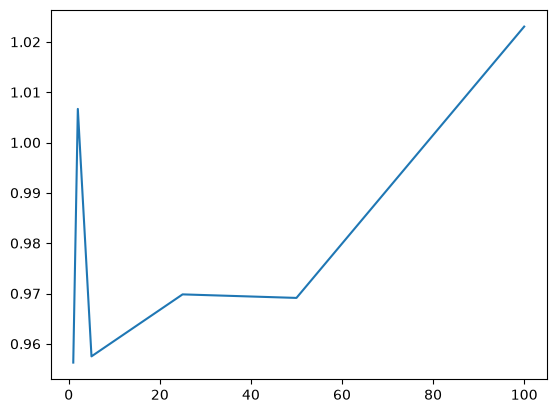

In [5]:
scores_wk = []
scores = []
for x in awake_times:
    model.genact_bern(pas, min_awake=x)
    reg, wk_reg = policy.eval(n_runs, graph=False)
    scores.append(reg)
    scores_wk.append(wk_reg)

plt.plot(awake_times, scores_wk)